# Analyse Exploratoire des Données (EDA)

Exploration et analyse du dataset des véhicules d'occasion pour comprendre les distributions, détecter les valeurs aberrantes et préparer les données.

In [ ]:
# Import des bibliothèques nécessaires
import numpy as np
import pandas as pd

# Bibliothèques de visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Chargement du dataset des voitures d'occasion
df = pd.read_csv("csv/used_cars_1M_2025.csv")
df.head(10)

,id,country,city,brand,model,year,mileage_km,price_usd,fuel_type,transmission,horsepower,doors,color,condition_score,days_on_market,is_electric
0,1,USA,Adamport,Chevrolet,Silverado,2011.0,185945.0,5903.0,Hybrid,Manual,486.0,3.0,Silver,7.6,285.0,0.0
1,2,France,Mahe,Toyota,Corolla,2017.0,141520.0,9277.0,Plug-in Hybrid,Automatic,473.0,4.0,Brown,4.5,34.0,0.0
2,3,Germany,Hettstedt,BMW,5 Series,2016.0,139091.0,18918.0,Gasoline,Automatic,298.0,4.0,Blue,4.6,27.0,0.0
3,4,Germany,Kulmbach,Honda,CR-V,2007.0,258093.0,5058.0,Gasoline,Automatic,99.0,5.0,White,4.6,362.0,0.0
4,5,USA,Port Cory,Hyundai,Elantra,2017.0,147560.0,16954.0,Hybrid,Automatic,236.0,5.0,Yellow,8.5,359.0,1.0
5,6,USA,Port Pamelaside,Chevrolet,Malibu,2023.0,121663.0,14785.0,Hybrid,Automatic,417.0,5.0,Orange,8.3,364.0,0.0
6,7,USA,Michaelborough,Subaru,Outback,2005.0,244427.0,4477.0,Gasoline,Automatic,402.0,4.0,White,7.5,153.0,0.0
7,8,UK,Donaldport,Ford,F-150,2002.0,284431.0,1752.0,Gasoline,Automatic,306.0,4.0,Green,6.9,136.0,0.0
8,9,Germany,Waldmünchen,Volkswagen,Golf,1999.0,335999.0,1777.0,Electric,Automatic,637.0,5.0,Blue,9.2,246.0,0.0
9,10,Germany,Kelheim,Toyota,Corolla,2004.0,360036.0,897.0,Gasoline,Automatic,590.0,4.0,Silver,7.6,73.0,1.0


In [ ]:
# Informations sur les types de données et les valeurs manquantes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919036 entries, 0 to 919035
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               919036 non-null  int64  
 1   country          903719 non-null  object 
 2   city             903719 non-null  object 
 3   brand            903719 non-null  object 
 4   model            903719 non-null  object 
 5   year             903719 non-null  float64
 6   mileage_km       903722 non-null  float64
 7   price_usd        903720 non-null  float64
 8   fuel_type        903719 non-null  object 
 9   transmission     903719 non-null  object 
 10  horsepower       903719 non-null  float64
 11  doors            903719 non-null  float64
 12  color            903719 non-null  object 
 13  condition_score  903719 non-null  float64
 14  days_on_market   903719 non-null  float64
 15  is_electric      903719 non-null  float64
dtypes: float64(8), int64(1), object(7)
mem

In [ ]:
# Suppression de la colonne ID (non pertinente pour l'analyse)
df.drop("id", axis=1, inplace=True)

In [ ]:
# Statistiques descriptives des variables numériques
df.describe()

,year,mileage_km,price_usd,horsepower,doors,condition_score,days_on_market,is_electric
count,903719.000000,9.037220e+05,9.037200e+05,903719.000000,903719.000000,903719.000000,903719.000000,903719.000000
mean,2009.983856,2.154178e+05,1.183441e+04,369.706028,4.150229,6.664922,182.614314,0.110150
std,8.941747,1.215646e+05,2.576251e+04,161.571696,0.726499,2.011761,105.095730,0.313077
min,1995.000000,-9.778595e+04,-4.653511e+04,90.000000,2.000000,0.000000,1.000000,0.000000
25%,2002.000000,1.214582e+05,2.433000e+03,230.000000,4.000000,5.300000,92.000000,0.000000
50%,2010.000000,2.155970e+05,6.617000e+03,370.000000,4.000000,6.900000,183.000000,0.000000
75%,2018.000000,3.077710e+05,1.632700e+04,510.000000,5.000000,8.300000,274.000000,0.000000
max,2025.000000,9.980786e+06,4.977625e+06,649.000000,5.000000,10.000000,364.000000,1.000000


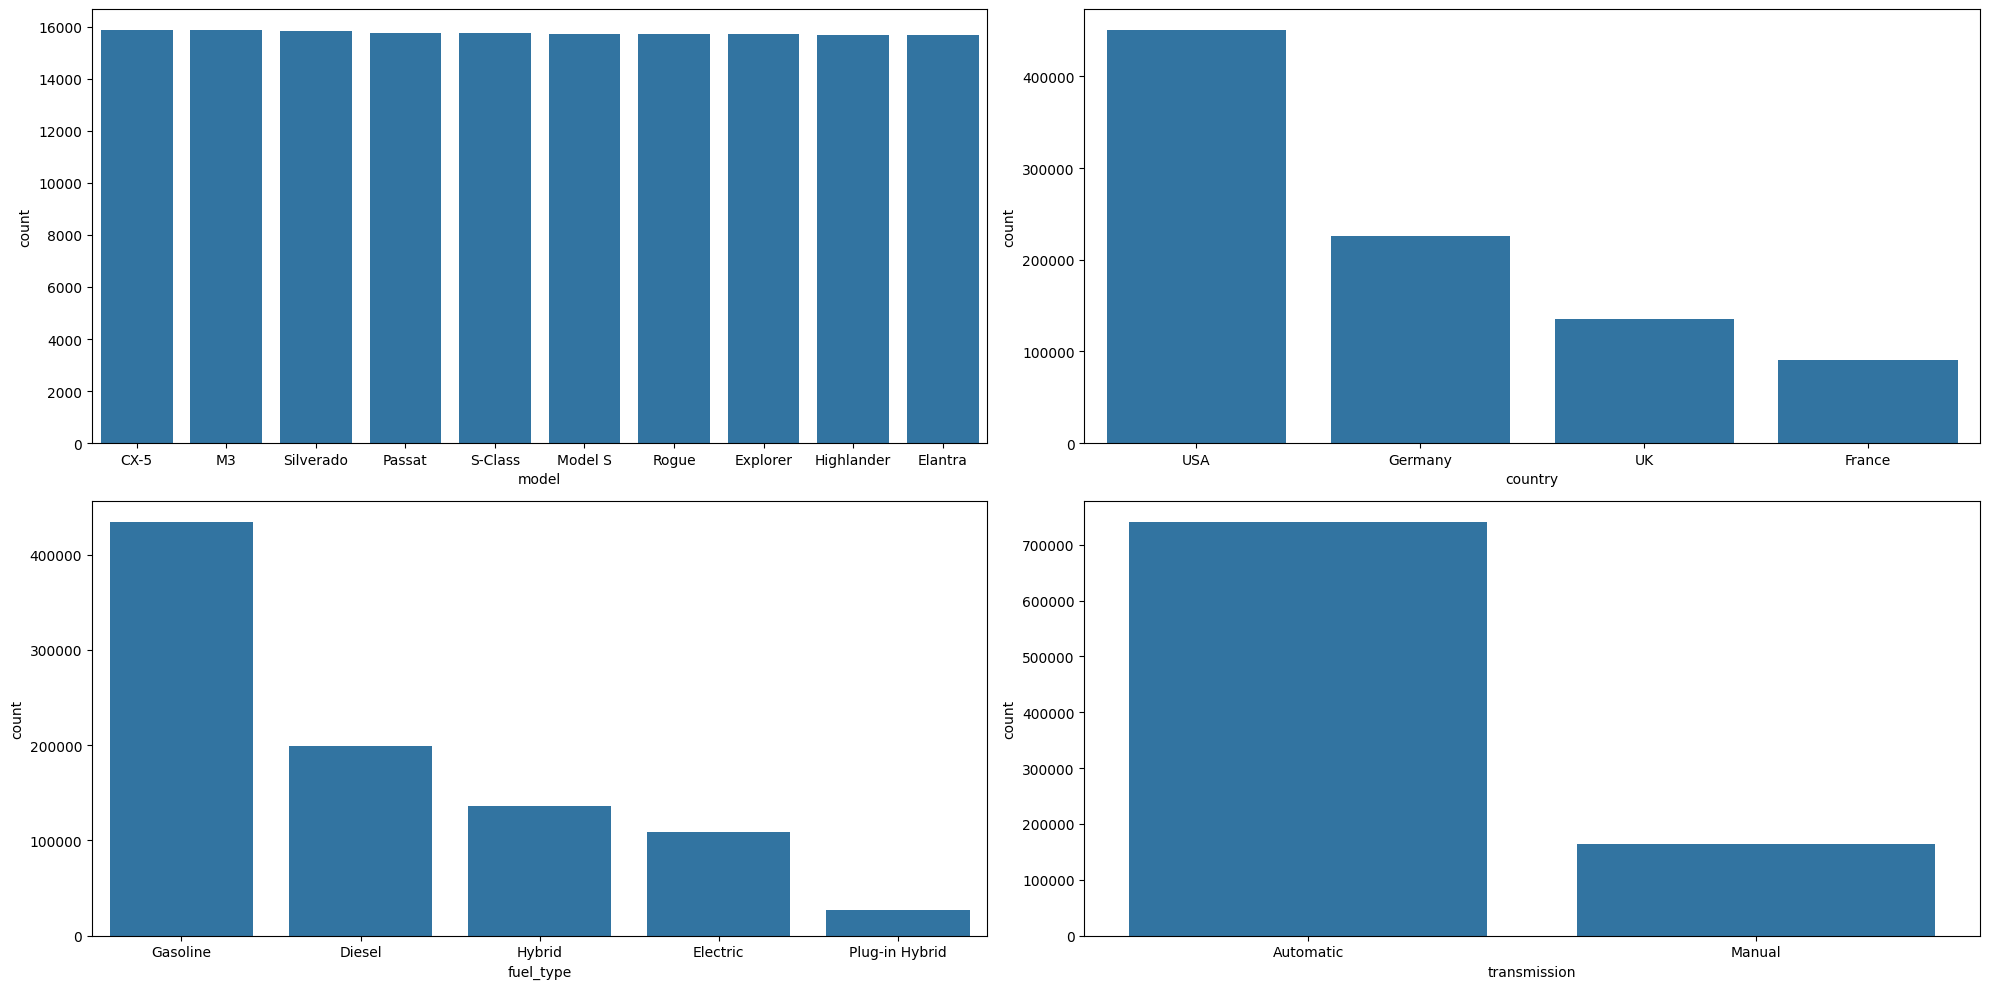

In [ ]:
# Visualisation des fréquences des variables catégorielles
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.countplot(data=df, x="model", ax=axes[0, 0], order=df["model"].value_counts().nlargest(10).index)
sns.countplot(data=df, x="country", ax=axes[0, 1], order=df["country"].value_counts().nlargest(10).index)
sns.countplot(data=df, x="fuel_type", ax=axes[1, 0], order=df["fuel_type"].value_counts().nlargest(10).index)
sns.countplot(data=df, x="transmission", ax=axes[1, 1], order=df["transmission"].value_counts().nlargest(10).index)

plt.tight_layout()
plt.show()

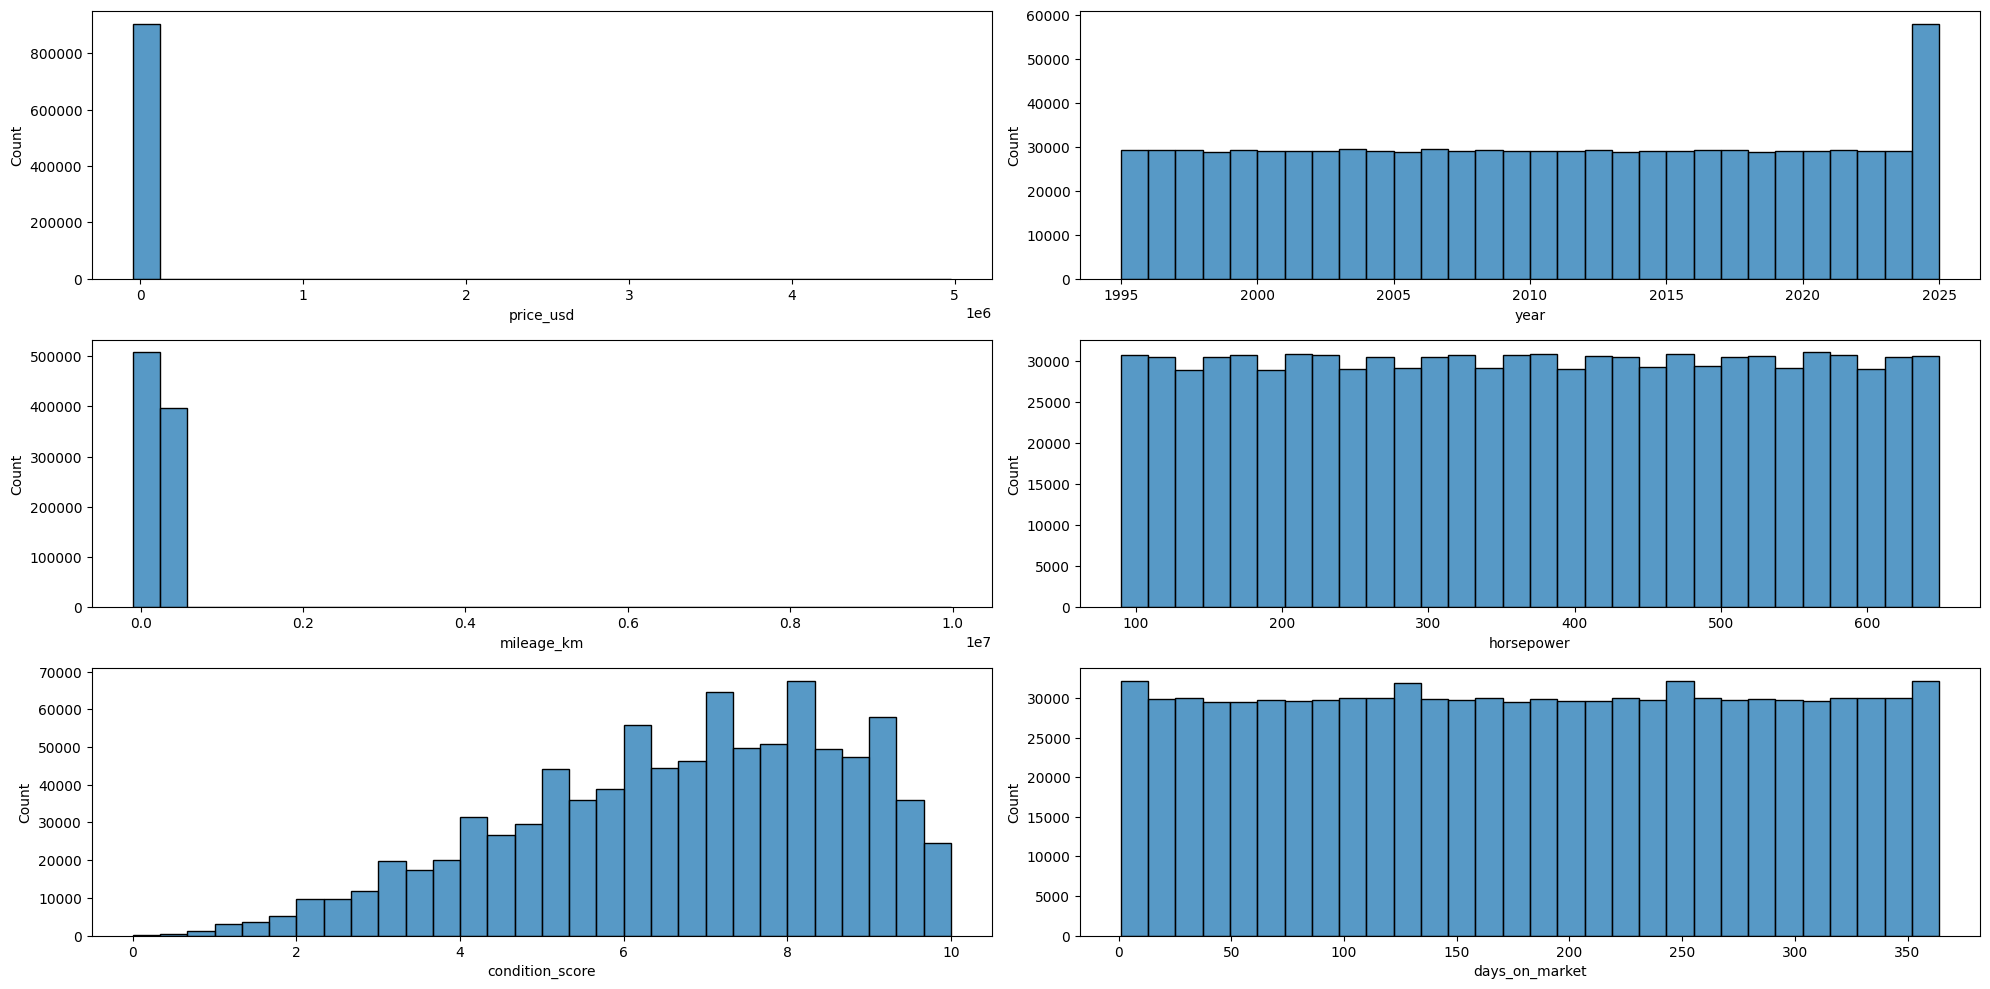

In [ ]:
# Distribution des variables numériques (histogrammes)
fig, axes = plt.subplots(3, 2, figsize=(20, 10))

sns.histplot(data=df, x="price_usd", ax=axes[0, 0], bins=30)
sns.histplot(data=df, x="year", ax=axes[0, 1], bins=30)
sns.histplot(data=df, x="mileage_km", ax=axes[1, 0], bins=30)
sns.histplot(data=df, x="horsepower", ax=axes[1, 1], bins=30)
sns.histplot(data=df, x="condition_score", ax=axes[2, 0], bins=30)
sns.histplot(data=df, x="days_on_market", ax=axes[2, 1], bins=30)

plt.tight_layout()
plt.show()

In [ ]:
# Vérification du nombre de valeurs manquantes par colonne
df.isnull().sum()

country            15317
city               15317
brand              15317
model              15317
year               15317
mileage_km         15314
price_usd          15316
fuel_type          15317
transmission       15317
horsepower         15317
doors              15317
color              15317
condition_score    15317
days_on_market     15317
is_electric        15317
dtype: int64

In [ ]:
# Traitement des valeurs manquantes : remplissage par la médiane et suppression
numeric_cols = ['price_usd', 'mileage_km', 'horsepower']
for col in numeric_cols:
    df[col].fillna(df[col].median())

df.dropna(inplace=True)

In [ ]:
# Vérification après traitement des valeurs manquantes
df.isnull().sum()

country            0
city               0
brand              0
model              0
year               0
mileage_km         0
price_usd          0
fuel_type          0
transmission       0
horsepower         0
doors              0
color              0
condition_score    0
days_on_market     0
is_electric        0
dtype: int64

In [ ]:
# Vérification du nombre de lignes dupliquées
df.duplicated().sum()

np.int64(39503)

In [ ]:
# Suppression des doublons et vérification
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

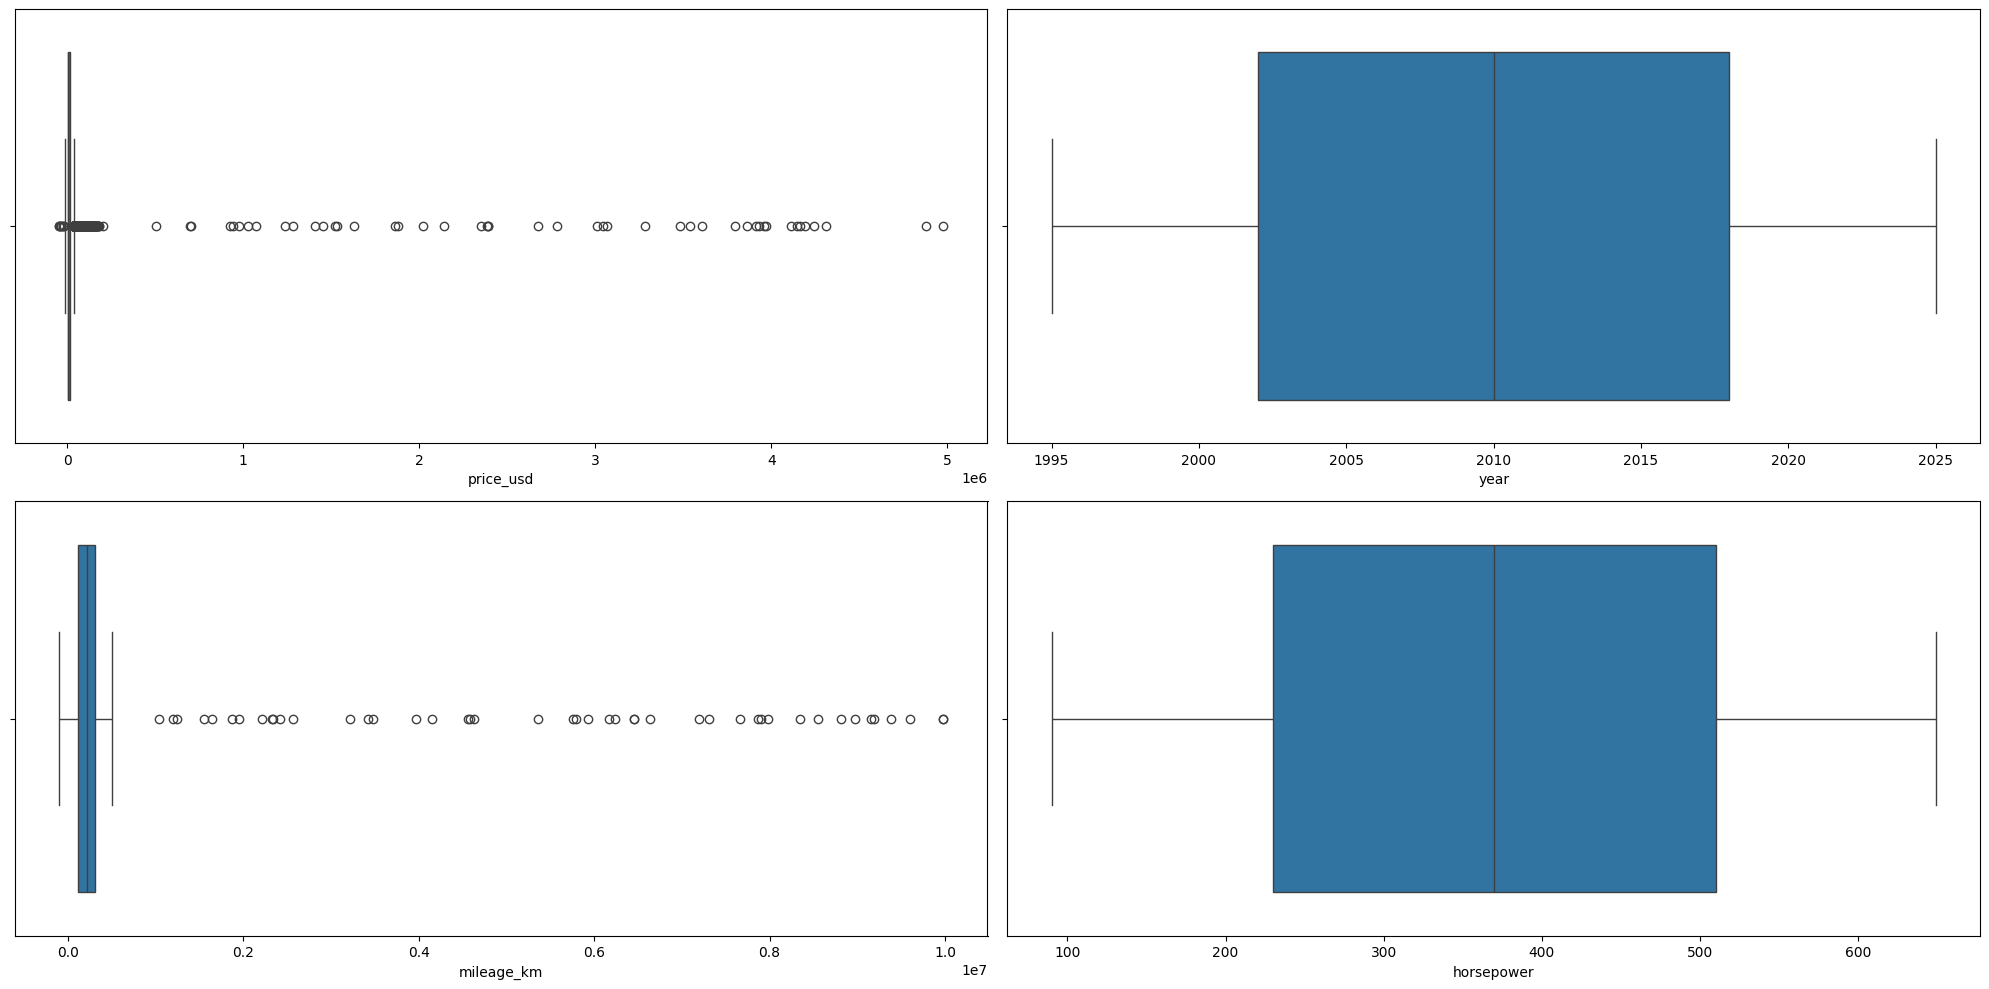

In [ ]:
# Détection des valeurs aberrantes avec des boxplots
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.boxplot(data=df, x="price_usd", ax=axes[0, 0])
sns.boxplot(data=df, x="year", ax=axes[0, 1])
sns.boxplot(data=df, x="mileage_km", ax=axes[1, 0])
sns.boxplot(data=df, x="horsepower", ax=axes[1, 1])

plt.tight_layout()
plt.show()

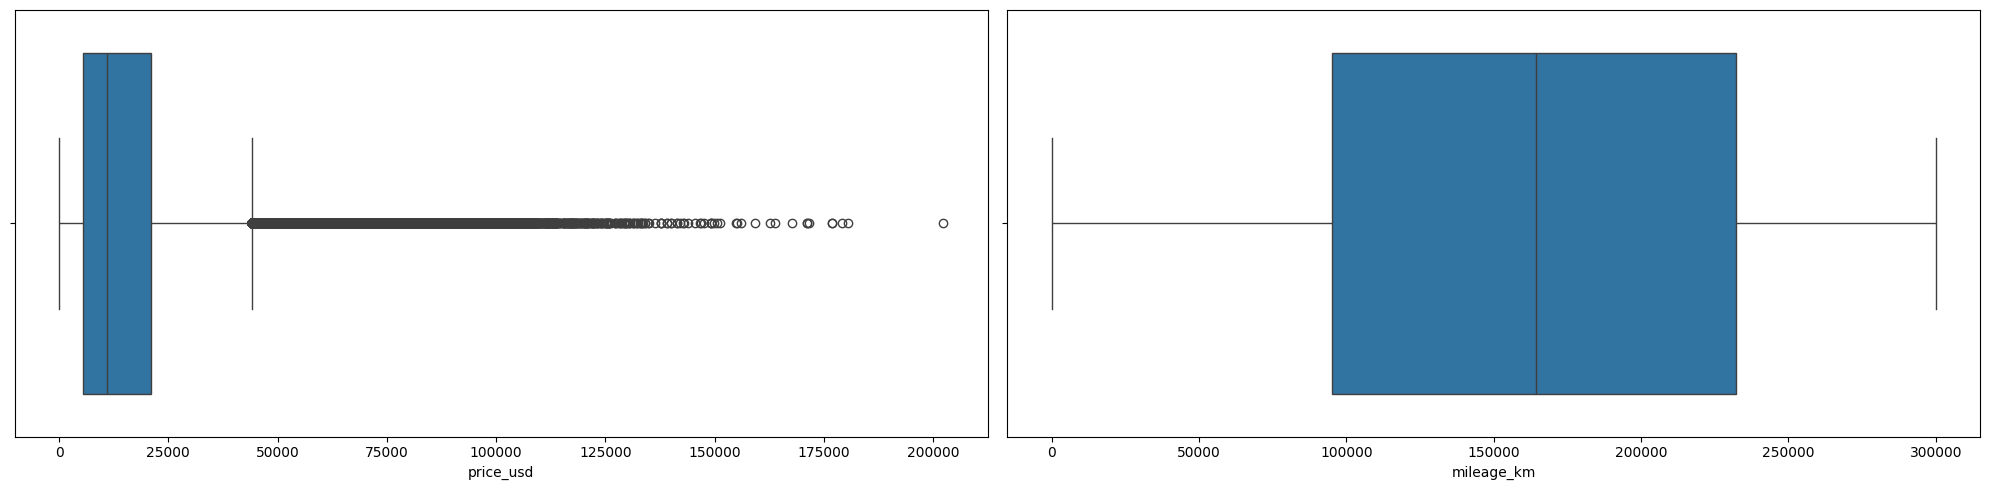

In [ ]:
# Suppression des valeurs aberrantes et visualisation après nettoyage
df = df.drop(df[(df["price_usd"] > 250000) | (df["price_usd"] < 0)].index)
df = df.drop(df[(df["mileage_km"] > 300000) | (df["mileage_km"] < 0)].index)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.boxplot(data=df, x="price_usd", ax=axes[0])
sns.boxplot(data=df, x="mileage_km", ax=axes[1])

plt.tight_layout()
plt.show()

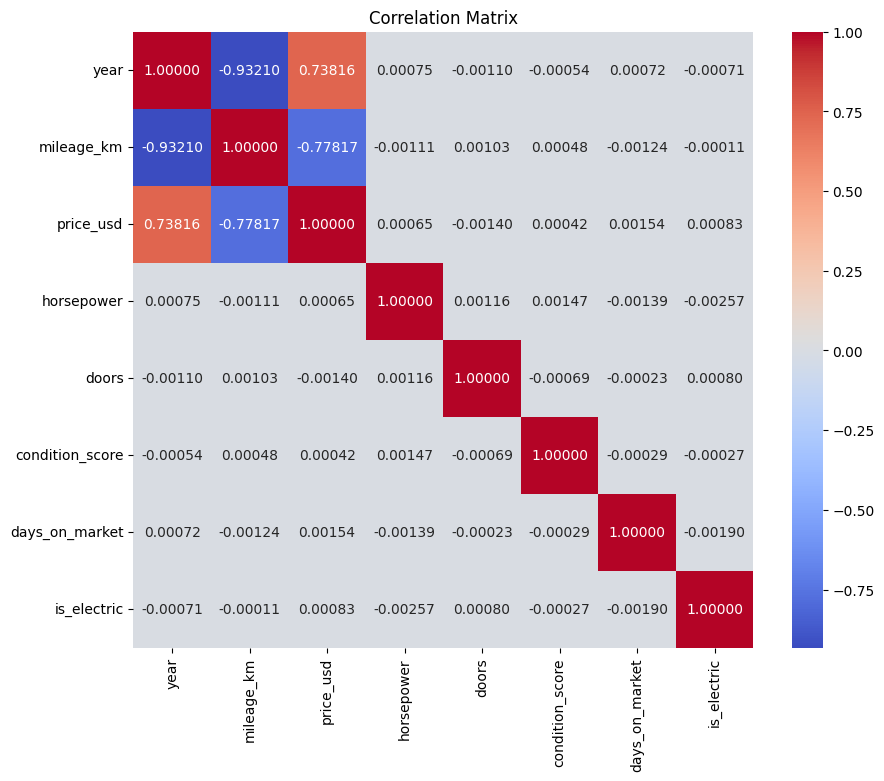

In [ ]:
# Matrice de corrélation entre les variables numériques
plt.figure(figsize=(10, 8))

corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".5f")

plt.title("Correlation Matrix")
plt.show()

On observe que price_usd est fortement corrélé avec horsepower et year, indiquant que les véhicules plus récents et plus puissants sont plus chers. À l'inverse.

De plus, on voit une corrélation négative entre mileage_km et le prix : plus un véhicule a de kilomètres, moins il est cher. On note également que les autres métriques ont très peu de relation avec le prix.